# Øving 1. Bildebehandling, diffusjon og Prims algoritme

## Lasting og vise et bilde

Vi kommer til å tenke på et bilde som en numpy array $f$. Verdien i f[i,j] inneholder tre floats, en for hver av fargene Rød, Grønn og Blå. Dette er et svart hvitt bilde så vi bruker kun en av disse kanalene. For å vise et bilde så bruker vi matplotlib.

Vi ser fra informasjonen om bildet at det er 500 x 375 piksler stort. Matrisen vi lager vil da ha samme størrelse.

Velg en av fargekanalene og legg dataene i en 375x500 nparray. 


<class 'numpy.ndarray'>
(375, 500, 3)
[134 134 134]
<class 'numpy.ndarray'>
(375, 500)
134


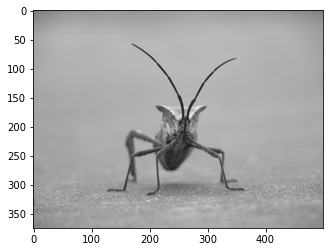

In [ ]:
%matplotlib inline
from PIL import Image
import matplotlib.pyplot as plt 
import numpy as np

# Importerer bildet
f = np.array(Image.open("image001.png"))

print(f"Datatypen til f er en {type(f)}\n med størelser {f.shape}.")

print(f"En piksel er på formen {f[10, 200]}. Som vi kan se er alle fargene like.")

# Plukker ut den røde fargekanalen.
f = f[:,:,0]

print(f"Datatypen til f er nå av type {type(f)}\n med størelser {f.shape}.")

print(f[10, 200])

# Plotter bildet som et svart-hvittbilde
plt.imshow(f, cmap="gray")


## 1. Gradienten og kantene i et bilde

Vi tenker på bildet som en numerisk tilnærming til en glatt funksjon $z=f(x,y)$. Vi skal regne ut en tilnærming til gradienten til denne funksjonen. Formelen vi bruker
er $$f_x(x,y) \approx \frac{f(x+\Delta x,y) - f(x-\Delta x,y)}{2\cdot \Delta x}$$ hvor $\Delta x = 1$, og tilsvarende for $f_y$.

Merk at vi bare kan regne ut $f_x$ for verdiene $x=1\dots 499$, siden vi bruker verdiene til siden for $x$ i utregningen.

## Oppgave 1

### a)

Regn ut verdiene for $f_x$ og legg dem i en matrise med navn fx. Matrisen fx har størrelse $500 \times 375$. Verdiene i fx skal være
0 der de ikke er definert.

Tegn deretter bilde til matrisen fx.

### b)

Regn ut verdiene for $f_y$ og legg dem i en matrise med navn fy. Matrisen fy har størrelse $500 \times 375$. Verdiene i fy skal være
0 der de ikke er definert. 

Tegn deretter bilde til matrisen fy.

### c) 

Regn ut lengden til gradienten i hvert punkt og legg dem i en matrise med navn fgradabs. Matrisen har størrelse $500\times 375$.
Verdiene skal være 0 der de ikke er definert.

Tegn bildet som tilhører matrisen fgradabs.

### d)

Finn minste og største verdi i matrisen fgradabs. Skaler deretter verdiene slik at de ligger mellom 0 og 1 og legg resultatet i 
en matrise med samme navn. Tegn bildet på nytt. Dere skal ha samme bilde som i c).

### e)

Les igjennom https://en.wikipedia.org/wiki/Edge_detection. 

Forklar hva vi mener når vi snakker om kanter i et bilde. Forklar hvordan gradienten vi har regnet ut kan brukes til å finne kantene i et bilde.

Det er lett å se med det blotte øye hva kantene bør være i akkurat dette bildet (hint: rundt insektet). Vi skal nå prøve ut noen algoritmer 
som finner disse kantene.

### f)

Les gjennom https://www.w3schools.com/python/numpy/numpy_ufunc_create_function.asp.  Dere bør være i stand til å lage din egen ufunc etter å ha lest dette. Dere skal også lære dere å bruke np.vectorize. Se https://numpy.org/doc/stable/reference/generated/numpy.vectorize.html

La $c$ være et tall mellom 0 og 1. Lag en matrise med navn "kanter" som har verdier 0 hvis verdien på samme plass i fgradabs er mindre enn eller lik $c$, og verdier $1$ hvis verdien i fgradabs er større enn $c$. Dvs. anvend funksjonen

```
def kutt(x):
    c = 0.5 # du kan prøve å endre på denne verdien
    if x <= c: return 0.0 else: return 1.0
```

på alle elementene fgradabs. Gjør dette ved å lage en numpy ufunc.


### g) 

Du har nettopp lært en algoritme for å finne kantene i et bilde. Prøv å finn en passende verdi for $c$ slik at problemet beskrevet i e) 
blir løst på en rimelig god måte. Hvordan synes dere algoritmen fungerer på akkurat dette bildet?




(375, 500)


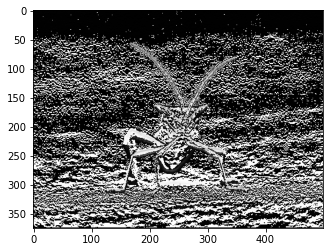

(375, 500)


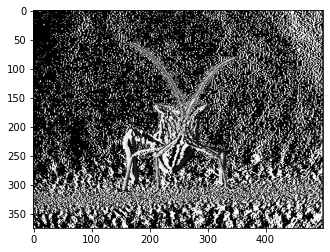

(375, 500)


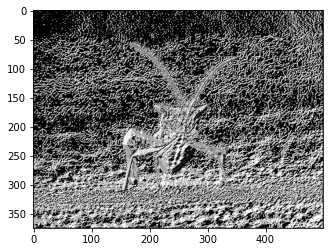

0.0
180.31222920256963


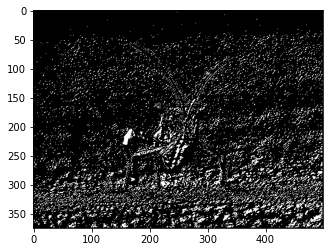

In [2]:

bshape = f.shape    # shape for bildet

fx = np.zeros(shape=bshape)
fx[1:-1, :] = (f[2:, :] - f[:-2, :]) / 2.0
print(fx.shape)
plt.imshow(fx, cmap="gray")
plt.show()

fy = np.zeros(shape=bshape)
fy[:,1:-1] = (f[:,2:] - f[:,:-2]) / 2.0
print(fy.shape)
plt.imshow(fy, cmap="gray")
plt.show()

fgradabs = np.zeros(shape=bshape)
fgradabs = np.sqrt(fx*fx + fy*fy)
print(fgradabs.shape)
plt.imshow(fgradabs, cmap="gray")
plt.show()

minverdi = np.min(fgradabs)
maxverdi = np.max(fgradabs)
print(minverdi)
print(maxverdi)
fgradabsskalert = fgradabs / (maxverdi - minverdi)

def kutt(x):
    c = 0.9
    if x > c: return 1.0
    else: return 0.0

kanter = np.vectorize(kutt)(fgradabsskalert)
kanter = kanter.astype('float64')
plt.imshow(kanter, cmap="gray")
plt.show()







## 2. Diffusjon og endringer i tid

Vi kommer til å se at gradient-metoden kan forbedres vi å bruke en diffusjon på bildet til å glatte ut og fjerne støy i bildet. Vi skal regne ut en sekvens av bilder $F(x,y,t)$ for 
stigende verdier av $t$. 

Ficks lover (https://no.wikipedia.org/wiki/Ficks_diffusjonslover) forklarer diffusjon som en bevaringslov med en spesielle type fluks.

En bevaringslov i en dimensjon tar formen

$$
\frac{\partial F}{\partial t} + \frac{\partial J}{\partial x} = 0,
$$

hvor $J(F,x,t)$ er fluks av stoffet $F$. Formen til $J$ bestemmes ut fra en fysisk modell. Noen viktiger eksempler:

1. $J = aF$ hvor $a$ er en konstant.
2. $J = aF^2$.
3. $J = a\frac{\partial F}{\partial x}$

I flere situasjoner har vi til og med en kombinasjon av alle 3, dvs

$$
J = a_1 F + a_2 F^2 + a_3\frac{\partial F}{\partial x}
$$

## Oppgave 2: 

### a)
Ficks først diffusjonslov sier at $J$ tar en av formene over. Hvilken?

### b)
Ficks andre diffusjonslov gir ligningen som følger fra $J$ og bevaringsloven. Hva blir den?

### c)
Hva representerer isåfall flukser av type 1 og 2? Oppgi situasjoner vår de ville vært passende.

### d)
Hva med den siste muligheten, dvs en summen av alle tre? Når gjelder den? Tror du at systemet vil oppføre seg mest som 1, 2 eller 3? Eller kommer det an på andre faktorer? 

### e)
Forklar hvorfor en bevaringslov for et stoff $F(x,y,t)$ med 2 dimensjoner tar formen

$$
\frac{\partial F}{\partial t} + \frac{\partial I}{\partial x} + \frac{\partial J}{\partial y}= 0,
$$

hvor fluksen $\vec{J} = (I, J)$ oppgis i henholdsvis $x-$ og $y-$ retninger.

## Løsning

### a)

Ficks er nummer 3

### b)

Vi får da

$$
\frac{\partial\varphi}{\partial t} = - \frac{\partial}{\partial x} a\frac{\partial\varphi}{\partial x} = -a\frac{\partial^2\varphi}{\partial x^2}
$$

### c)

Nummer 1 er lineær adveksjon/konveksjon/transport, f eks masstransport i en stadig strøm. Nummer 2 er ikke lineær, for farten er avhengig av konsentrasjon, f eks momentumtransport i en væske (gir dermed hastighet)

### d)

Da får vi en blanding, f eks varmetransport som skyldes både konveksjon og diffusjon. Hvordan systemet oppfører seg kommer an på de relative størrelsene av a1, a2, og a3. Men legg merke til at $a3=0$ er noe annet enn $a3\rightarrow 0$, gitt den kraftige utjevning av diffusjon.

### e)

Vi setter opp en liten rektangel av areal $\delta x \delta y$: endring i tid av $F$ er $\frac{\partial I}{\partial x}$ for fluks over randene parallelt med $y$-aksen, og $\frac{\partial J}{\partial y}$ over randene parallelt med $x$-aksen, osv.

## 3. Diffusjon på bilde

Vi lar endringen av gråfargen med hensyn på $t$ være gitt ved 

$$
F_t = I_x + J_y,
$$

hvor $I = g\cdot F_x$, og $J=g\cdot F_y$, og $g$ er konstanten $1$ i denne
oppgaven.

Vi får altså 

$$F_{t} = g \cdot \Delta F$$ hvor $$\Delta F = F_{xx} + F_{yy}$$ 

Vi skal starte med bildet over, slik at vi har initialverdibetingelsen $$F(x,y,0)=f(x,y).$$

Vi ønsker ikke at fargen skal gå ut eller komme inn i bildet, slik at vi trenger betingelsen $F_x = 0$ for venstre og høyre kant i bildet, og $F_y=0$ for
øvre og nedre kant i bildet. Merk at utregningen av de partiellderiverte i forrige oppgave tilfredstiller disse to betingelsene.

Vi bruker forlengs Euler for integrasjonen. Ved steg $t$ så har vi $$\frac{F(x,y,t+\Delta t) - F(x,y,t)}{\Delta t} \approx F_{xx} + F_{yy},$$ det vil si vi får oppdateringen $$F(x,y,t+\Delta t) = F(x,y,t) + \Delta t \cdot (F_ {xx} + F_{yy})$$
som vi gjennomfører et gitt antall ganger.

Faktoren $\Delta F = F_{xx} + F_{yy}$ må tilnærmes numerisk. Vi bruker $$F_{xx}(x,y) \approx \frac{F_x(x+\Delta x) - F_x(x-\Delta x)}{2\Delta x}$$ og tilsvarende
for $F_{yy}$.

Vi må ha steg $\Delta t$ som er små nok. Dere kan eksperimentere med ulike verdier, hvor dere starter med $\Delta t = 0.5$. 

## Oppgave 3

### a) 

Implementer integrasjonen beskrevet over og vis bildene som lages.

### b) 

Eksperimenter med ulike antall oppdateringer og ulike verdier for $\Delta t$ i a). Beskriv hva du observerer.

### c)

Gjennomfør analysen fra Oppgave 1 for bildet som blir generert fra a). Prøv å finn en god kombinasjon av verdier for $c$, $\Delta t$ og antall oppdateringer slik at 
algoritmen fra Oppgave 1 kombinert med det diffuserte bilde gir en rimelig god beskrivelse av kantene i bildet. 

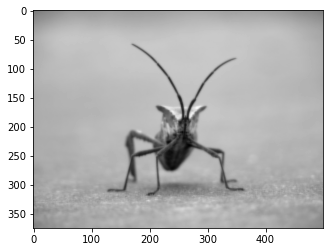

(375, 500)


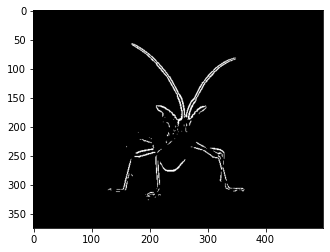

In [3]:

dt = 0.1
numstep = 10

F = np.zeros(shape=bshape)
F[:,:] = f[:,:]
Fx = np.zeros(shape=bshape)
Fy = np.zeros(shape=bshape)
Fxx = np.zeros(shape=bshape)
Fyy = np.zeros(shape=bshape)


for i in range(numstep):
    Fx[1:-1,:] = (F[2:,:] - F[:-2,:]) / 2.0
    Fy[:,1:-1] = (F[:,2:] - F[:,:-2]) / 2.0
    Fxx[1:-1,:] = (Fx[2:,:] - Fx[:-2,:]) / 2.0
    Fyy[:,1:-1] = (Fy[:,2:] - Fy[:,:-2]) / 2.0
    F[1:-1,1:-1] = F[1:-1,1:-1] + dt * (Fxx[1:-1,1:-1] + Fyy[1:-1,1:-1])

plt.imshow(F, cmap="gray")
plt.show()

Fgradabs = np.sqrt(Fx*Fx + Fy*Fy)
minverdi = np.min(Fgradabs)
maxverdi = np.max(Fgradabs)
Fgradabsskalert = Fgradabs / (maxverdi - minverdi)

def kutt(x):
    c = 0.3
    if x > c: return 1.0
    else: return 0.0

kanter = np.vectorize(kutt)(Fgradabsskalert)
kanter = kanter.astype('float64')
print(kanter.shape)
plt.imshow(kanter, cmap="gray")
plt.show()



## 4. Mer diffusjon på et bilde 

Vi skal igjen prøve å glatte ut bildet med diffusjon med differensiallikningen 

$$
F_t = I_x + J_y,
$$

hvor $I = g\cdot F_x$, og $J=g\cdot F_y$, men denne gangen er $g$ funksjonen $$g(|\nabla F|)= \frac{1}{\sqrt{1 + \frac{|\nabla F|^2}{\lambda ^2}}}$$ for et tall $\lambda$. Merk at hvis $g$ er en konstant så har vi samme differensiallikning som i forrige oppgave. 

Ideen er at å velge en passende verdi for $\lambda$ vil gi en diffusjon hvor de skarpe kantene blir bevart lengre i diffusjonen. 

## Oppgave 4

### a) 

Tegn grafen til $g(x)$ for ulike verdier av $\lambda$. 

#### i) 

Hva vil $g(|\nabla F|)$ gjøre med store verdier av $|\nabla F|$? 

#### ii) 

Hva vil $g(|\nabla F|)$ gjøre med små verdier av $|\nabla F|$? 

#### iii) 

Hvilken innflytelse har $\lambda$ for hva som skjer i) og ii)?

### b) 

Implementer integrasjonen beskrevet over og vis bildene som lages.

### c) 

Eksperimenter med ulike antall oppdateringer og ulike verdier for $\Delta t$  og $\lambda$ i b). Beskriv hva du observerer.

Hvilken innflytelse har ulike verdier for $\lambda$ på resultatene?

### d)

Gjennomfør analysen fra Oppgave 1 for bildet som blir generert fra b). Prøv å finn en god kombinasjon av verdier for $c$, $\lambda$, $\Delta t$ og antall oppdateringer slik at vi får en god beskrivelse av kantene i bildet. 



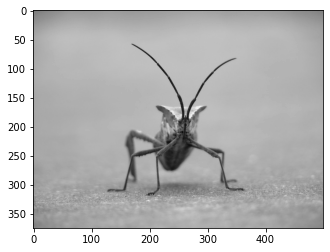

(375, 500)


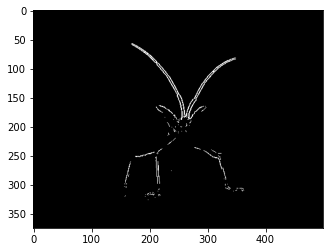

In [4]:
import math as m

dt = 0.1
numstep = 3

F = np.zeros(shape=bshape)
F[:,:] = f[:,:]

Fx = np.zeros(shape=bshape)
Fy = np.zeros(shape=bshape)

def gval(x,y):
    lsq = 1000.0
    gr = x*x + y*y
    return 1 / m.sqrt(1 + gr / lsq)

g = np.zeros(shape=bshape)
gFx = np.zeros(shape=bshape)
gFy = np.zeros(shape=bshape)
gFxx = np.zeros(shape=bshape)
gFyy = np.zeros(shape=bshape)

for i in range(numstep):
    Fx[1:-1,:] = (F[2:,:] - F[:-2,:]) / 2.0
    Fy[:,1:-1] = (F[:,2:] - F[:,:-2]) / 2.0
    g = np.frompyfunc(gval,2,1)(Fx, Fy)
    gFx = g * Fx
    gFy = g * Fy
    gFxx[1:-1,:] = (gFx[2:,:] - gFx[:-2,:]) / 2.0
    gFyy[:,1:-1] = (gFy[:,2:] - gFy[:,:-2]) / 2.0
    
    F[1:-1,1:-1] = F[1:-1,1:-1] + dt * (gFxx[1:-1,1:-1] + gFyy[1:-1,1:-1])


plt.imshow(F, cmap="gray")
plt.show()

Fgradabs = np.sqrt(Fx*Fx + Fy*Fy)
minverdi = np.min(Fgradabs)
maxverdi = np.max(Fgradabs)
Fgradabsskalert = Fgradabs / (maxverdi - minverdi)

def kutt(x):
    c = 0.3
    if x > c: return 1.0
    else: return 0.0

kanter = np.vectorize(kutt)(Fgradabsskalert)
kanter = kanter.astype('float64')
print(kanter.shape)
plt.imshow(kanter, cmap="gray")
plt.show()


## Oppgave 5: Prims algoritme

Vi skal se på hvordan Prims algoritme til å lage et level for et roguelike spill. Hvis du ikke vet hva en roguelike er for noe, så kan du lese 

https://en.wikipedia.org/wiki/Roguelike

Vi skal bruke en matrise vi kaller 'level' til å beskrive et level. Rommene ligger i level[i,j] for odde verdier av i og j. Hvis i eller j er partall så er level[i,j] en vegg. Alle rom skal ha verdien 1.0. Alle vegger skal i utkangspunktet ha verdien $0$.
Størrelsen på matrisen er $21\times 21$.

### a)

Lag matrisen 'level' og tegn matrisen med imshow.

### b)

'level[i,j]' der i eller j (men ikke begge) partall er en vegg som kan fjernes, dvs. verdien settes til $1.0$. Dette åpner veggen mellom to
rom.

Med utganspunkt i matrisen fra a), lag et algoritme som setter 'level[i,j]=1.0$ for $20$ ulike men tilfeldige par (i,j), der 

- en av i og j, men ikke begge, er partall, og
- der det ikke gjelder at: $i=0$, $j=0$, $i=20$ eller $j=20$ 

Tegn matrisen.

### c)

Gå tilbake til matrisen fra a).

Vi skal åpne vegger ( dvs. level[i,j] = 1.0 der akkurat en av indeksene er odde ) slik at det er mulig å gå fra ethvert rom til ethvert
annet rom på akkurat en måte. 

Vi kan tenke oss en graf hvor rommene ( indekser (i,j) der i og j er begge odde) er noder og vegger mellom rom med level[i,j]=1 er kanter.
At 'det er mulig å gå fra ethvert rom til ethvert annet rom på akkurat en måte' er ekvivalent med å si at denne grafen er et tre.

Hvilke vegger som skal åpnes skal være tilfeldig. Å åpne en vegg er ekvivalent med å legge en kant inn i grafen.

Først:

- Vi starter med en graf der hver mulig kant (dvs. vegg der i eller j er odde, men ikke begge) har en tilfeldig vekt mellom 0.0 og 1.0. Merk at vegger rundt randen (i=0, j=0, i=20 eller j=20) skal alltid være lukket, så disse er ikke en del av grafen.

- Vi kjører prims algoritme på grafen og lager et utspennende tre. Algoritmen skal starte med rommet øverst til venstre.

Til slutt lager vi en matrise, der kanter som velges av prims algoritme får verdi 1.0 og kanter som ikke velges av algoritmen får verdi 0.0.

Tegn bildet til matrisen.

Merk at vegger rundt randen (i=0, j=0, i=20 eller j=20) skal alltid være lukket.


### Kodekrav til dette spørsmålet

du kan importere modulen random og numpy, men skal ellers ikke importere noen moduler. 

Du bør løse problemet ved hjelp av innebygde datastrukturer i Python som f.eks. lister, ordbøker, tupler og mengder. Du kan bruke metodene på disse, som f.eks. sort og append m.m.

Ikke lag klasser. Hvis du plutselig begynner å tenke "her må jeg ha en klasse", så stop med en gang, ta en listen pause, innse at dette ikke blir så lett som du tror, og tenk litt mer på løsningen.

Løsningen vår var rundt 20 linjer. Det er greit om du skriver lang kode, men det er ikke nødvendig.


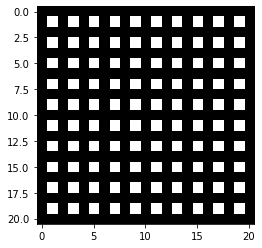

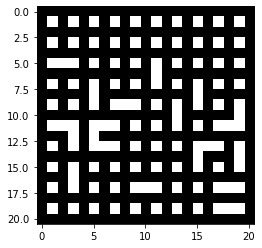

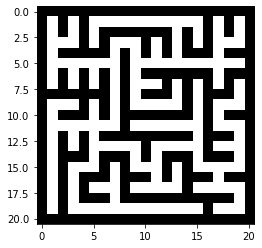

In [5]:
import numpy as np

levelshape = (21,21)
level = np.zeros(shape=levelshape)
level[1::2, 1::2] = 1.0

plt.imshow(level,cmap="gray")
plt.show()

from copy import deepcopy

pairs = [(i,j) for i in range(21) for j in range(21)]
pairs = [(i,j) for (i,j) in pairs if not (i==0 or i==20 or j==0 or j==20)]
pairs = [(i,j) for (i,j) in pairs if (i % 2 and not j % 2) or (j % 2 and not i % 2)]
savedpairs = deepcopy(pairs)

from random import shuffle
from random import random

shuffle(pairs)
pairs = pairs[:20]

for (i,j) in pairs:
    level[i,j] = 1.0

plt.imshow(level,cmap="gray")
plt.show()

pairs = savedpairs
graph = { edge : random() for edge in pairs }

past = {(1,1)}

def valid(i,j):
    p = (i+(i+1)%2), (j+(j+1)%2)
    q = (i-(i+1)%2), (j-(j+1)%2) 
    return p in past and not q in past or not p in past and q in past

chosen = []

while 1:
    nhd = [(i,j) for (i,j) in pairs if valid(i,j)]
    if not nhd: break
    nhd.sort(key = lambda p : graph[(p[0],p[1])])
    chosen.append(nhd[0])
    i, j = nhd[0]
    past = past.union({(i+(i+1)%2, j+(j+1)%2), (i-(i+1)%2, j-(j+1)%2)})

level[:,:] = 0.0
level[1::2, 1::2] = 1.0
for p in chosen:
    level[p[0],p[1]] = 1.0

plt.imshow(level, cmap="gray")
plt.show()
